# Model Drift Detection — Credit Risk

This notebook demonstrates detecting data drift between a **baseline period** (e.g. last quarter's applicants) and a **current period** (this quarter's applicants) using:

- **Population Stability Index (PSI)** — measures how much a feature's distribution has shifted
- **Kolmogorov-Smirnov (KS) Test** — statistical test for whether two samples come from the same distribution

Drift matters because a credit risk model trained on old data may make unreliable decisions if the applicant population has changed.

import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from drift_detection import population_stability_index, ks_test_drift, check_feature_drift

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
baseline = pd.read_csv('../data/baseline_period.csv')
current = pd.read_csv('../data/current_period.csv')

print("Baseline shape:", baseline.shape)
print("Current shape:", current.shape)
baseline.head()

Baseline shape: (2000, 5)
Current shape: (2000, 5)


,credit_score,debt_to_income,annual_income,credit_utilization,num_open_accounts
0,674.835708,0.245986,47047.595926,0.149323,5
1,643.086785,0.288439,59531.947666,0.172970,10
2,682.384427,0.236606,60270.253081,0.539754,1
3,726.151493,0.275363,67089.455188,0.206381,5
4,638.292331,0.148511,39497.124551,0.554930,4


## Drift Analysis Across All Features

Below we run PSI and the KS test on every feature to identify which ones have drifted between the baseline and current periods.

In [4]:
features = ['credit_score', 'debt_to_income', 'annual_income', 'credit_utilization', 'num_open_accounts']

drift_report = check_feature_drift(baseline, current, features)
drift_report

,feature,psi,psi_flag,ks_statistic,ks_p_value,ks_drift_detected
0,credit_score,0.464565,significant,0.2855,3.357208e-72,True
1,debt_to_income,0.006603,none,0.0170,9.348273e-01,False
2,annual_income,0.027077,none,0.0600,1.489409e-03,True
3,credit_utilization,0.711174,significant,0.3365,1.069478e-100,True
4,num_open_accounts,0.003268,none,0.0260,5.085995e-01,False


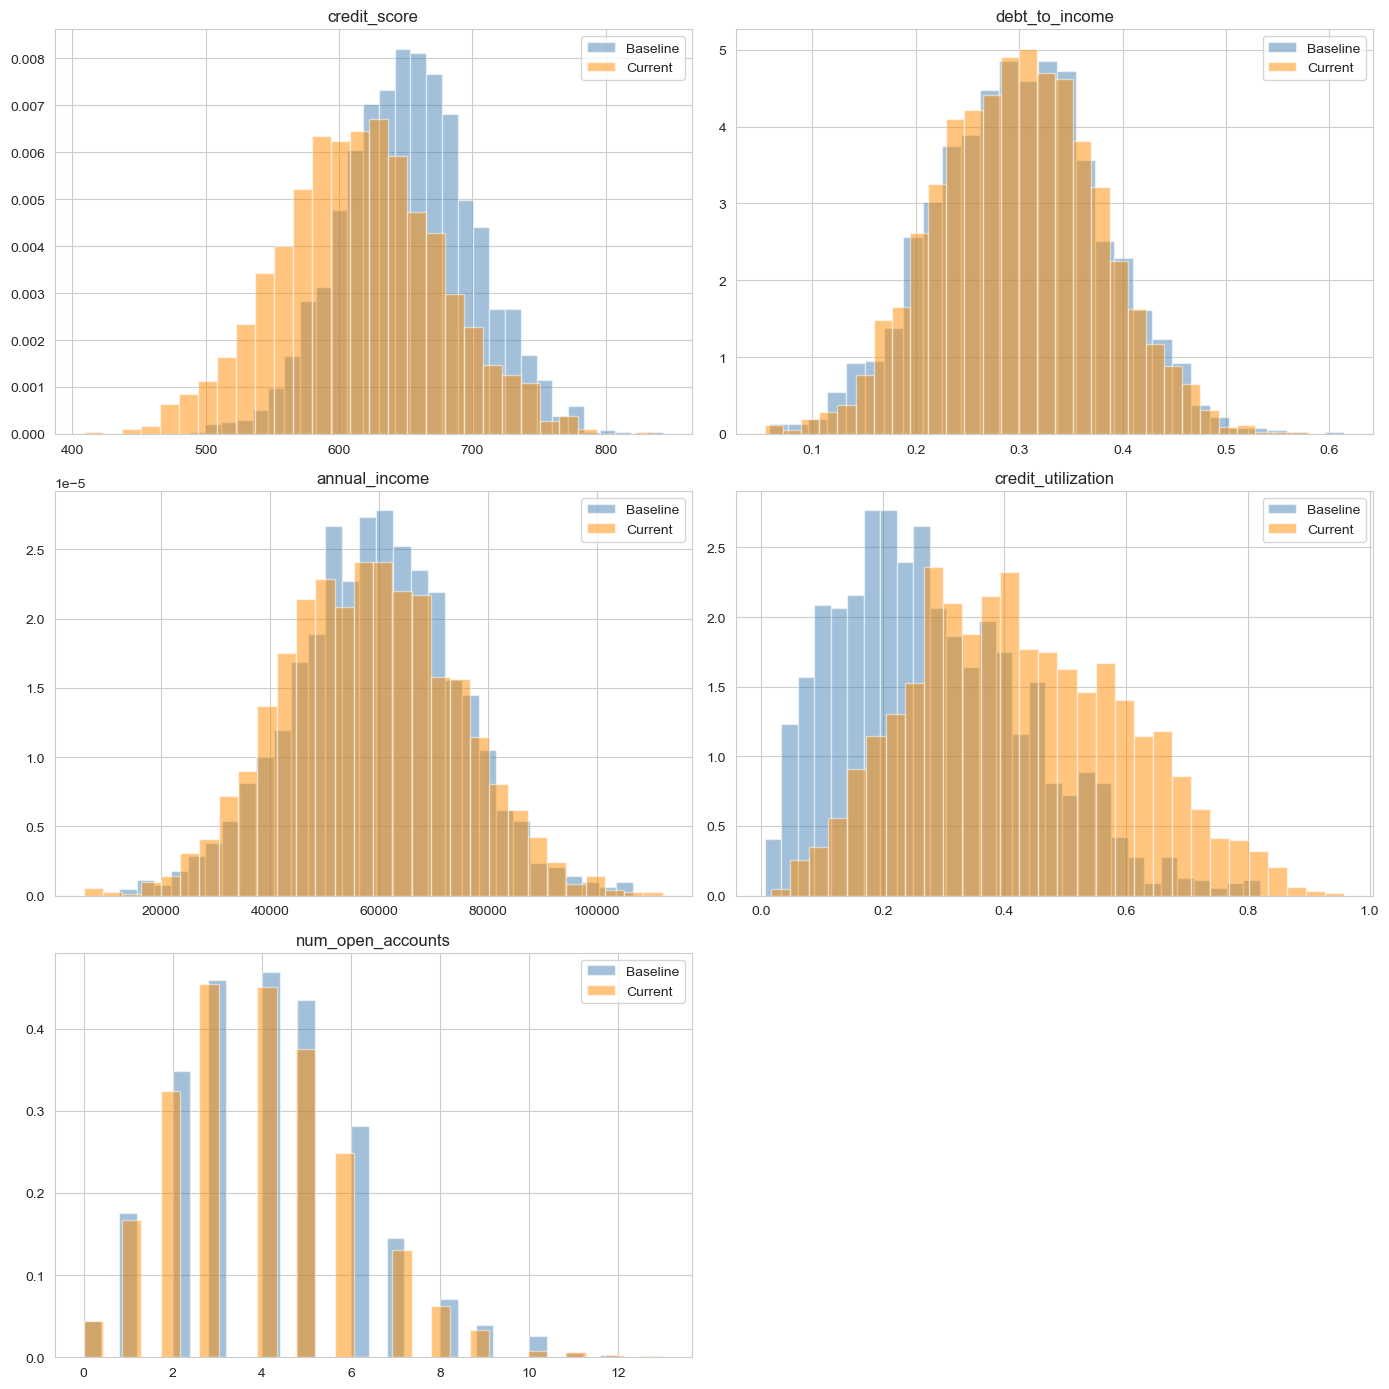

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(baseline[feature], bins=30, alpha=0.5, label='Baseline', color='steelblue', density=True)
    axes[i].hist(current[feature], bins=30, alpha=0.5, label='Current', color='darkorange', density=True)
    axes[i].set_title(feature)
    axes[i].legend()

# Hide the unused 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

## Conclusions

Based on the PSI and KS test results:

- **credit_score** and **credit_utilization** show significant drift between the baseline and current periods. This suggests the applicant population has meaningfully changed — likely warranting model retraining or closer monitoring of decisions made using these features.
- **debt_to_income**, **annual_income**, and **num_open_accounts** show no meaningful drift, indicating these features remain stable and reliable for the current model.

### Why this matters for credit risk
A credit risk model trained on the baseline population may under- or over-estimate risk for applicants in the current period, particularly around credit utilization and credit score. In a production setting, detecting this drift early allows a team to:
1. Investigate the root cause (e.g. economic conditions, marketing channel changes, policy changes)
2. Decide whether to retrain the model on more recent data
3. Flag affected predictions for manual review in the interim